The objective of this project is to segment customers based on their purchasing behavior to support targeted marketing strategies. Customer, product, and order data will be organized in a SQLite database, and RFM analysis and KMeans clustering will be used to identify customer segments, justify the number of clusters, and describe each segment’s key characteristics.

In [21]:
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

import sqlite3


In [5]:
df=pd.read_csv('PBL5recommendationdata.csv', encoding="latin-1")

### Data Clarification

In [7]:
df.shape

(4194, 181)

In [8]:
df.isnull().sum()

Customers.id                0
Customers.fname             0
Customers.lname             0
Customers.company        3467
Customers.create_date       0
                         ... 
Products.leg_style       4194
Products.seat_size       4032
Products.family_id        325
Products.saved_status     264
Products.freight_cost    4194
Length: 181, dtype: int64

In [9]:
df.columns

Index(['Customers.id', 'Customers.fname', 'Customers.lname',
       'Customers.company', 'Customers.create_date', 'Customers.status',
       'Customers.mailing', 'Customers.reminders', 'Customers.tax_exempt',
       'Customers.account_id',
       ...
       'Products.google_shopping_label', 'Products.product_option',
       'Products.size', 'Products.material', 'Products.arm_style',
       'Products.leg_style', 'Products.seat_size', 'Products.family_id',
       'Products.saved_status', 'Products.freight_cost'],
      dtype='str', length=181)

In [71]:
pd.set_option("display.max_columns", None)
df.head()

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
missing = df.isna().sum()
print(missing[missing > 0].sort_values(ascending=False))

Customers.reminders      4194
Orders.shipping_trans    4194
Customers.profile_id     4194
Customers.rewards        4194
Customers.sales_rep      4194
                         ... 
Orders.updated_date        23
Orders.payment_date        18
Orders.payment_amount      18
Orders.payment_status       5
Order_Items.cost            3
Length: 161, dtype: int64


In [13]:
df = df.dropna(axis=1, how="all")
print(df.shape)

(4194, 147)


In [14]:
on_ekler = df.columns.str.split(".").str[0]

print(on_ekler.unique())
print(on_ekler.value_counts())

Index(['Customers', 'Orders', 'Order_Items', 'Products'], dtype='str')
Products       84
Orders         42
Customers      11
Order_Items    10
Name: count, dtype: int64


In [16]:
df.columns[on_ekler == "Order_Items"]

Index(['Order_Items.id', 'Order_Items.parent', 'Order_Items.product_id',
       'Order_Items.product_name', 'Order_Items.attribute_names',
       'Order_Items.qty', 'Order_Items.price', 'Order_Items.cost',
       'Order_Items.reorder_frequency', 'Order_Items.flags'],
      dtype='str')

In [17]:
customers = df.loc[:, on_ekler == "Customers"]
customers = customers.drop_duplicates(subset="Customers.id")

In [18]:
products = df.loc[:, on_ekler == "Products"]
products = products.dropna(subset=["Products.id"])
products = products.drop_duplicates(subset="Products.id")

In [19]:
orders = df.loc[:, on_ekler.isin(["Orders", "Order_Items"])]

In [20]:
print("customers:", customers.shape)
print("products :", products.shape)
print("orders   :", orders.shape)

customers: (3054, 11)
products : (1710, 84)
orders   : (4194, 52)


In [22]:
conn = sqlite3.connect("customer_segmentation.db")

In [23]:
customers.to_sql("Customer", conn, if_exists="replace", index=False)
products.to_sql("Products", conn, if_exists="replace", index=False)
orders.to_sql("Orders", conn, if_exists="replace", index=False)

4194

In [24]:
pd.read_sql_query(
    "SELECT name FROM sqlite_master WHERE type='table'",
    conn
)

,name
0,Customer
1,Products
2,Orders


In [25]:
conn.close()

In [26]:
conn = sqlite3.connect("customer_segmentation.db")

In [27]:
pd.read_sql("SELECT name FROM sqlite_master WHERE type='table'", conn)

,name
0,Customer
1,Products
2,Orders


In [30]:
customers_db = pd.read_sql("SELECT * FROM Customer", conn)
products_db  = pd.read_sql("SELECT * FROM Products", conn)
orders_db    = pd.read_sql("SELECT * FROM Orders", conn)

In [31]:
print(orders_db.columns.tolist())

['Orders.id', 'Orders.customer_id', 'Orders.fname', 'Orders.lname', 'Orders.company', 'Orders.order_number', 'Orders.reorder_id', 'Orders.external_source', 'Orders.external_id', 'Orders.currency', 'Orders.subtotal', 'Orders.tax', 'Orders.shipping', 'Orders.coupon_id', 'Orders.coupon_amount', 'Orders.fee_name', 'Orders.fee_amount', 'Orders.discount_name', 'Orders.discount_amount', 'Orders.total', 'Orders.balance_due', 'Orders.shipping_carrier', 'Orders.shipping_method', 'Orders.weight', 'Orders.tracking', 'Orders.payment_status', 'Orders.payment_date', 'Orders.payment_user', 'Orders.payment_type', 'Orders.payment_method', 'Orders.payment_amount', 'Orders.payment_id', 'Orders.payment_code', 'Orders.status', 'Orders.placed_date', 'Orders.updated_date', 'Orders.shipped_date', 'Orders.comments', 'Orders.notes', 'Orders.flags', 'Orders.partial_ship', 'Orders.customer_type', 'Order_Items.id', 'Order_Items.parent', 'Order_Items.product_id', 'Order_Items.product_name', 'Order_Items.attribute_na

In [32]:
merged = orders_db.merge(
    customers_db,
    left_on="Orders.customer_id",
    right_on="Customers.id",
    how="left"
)

merged = merged.merge(
    products_db,
    left_on="Order_Items.product_id",
    right_on="Products.id",
    how="left"
)

print(merged.shape)

(4194, 147)


### RFM Analysis

In [33]:
date_columns = [
    col for col in merged.columns
    if "date" in col.lower()
]

print(date_columns)

['Orders.payment_date', 'Orders.placed_date', 'Orders.updated_date', 'Orders.shipped_date', 'Customers.create_date']


In [34]:
merged[date_columns].head()

,Orders.payment_date,Orders.placed_date,Orders.updated_date,Orders.shipped_date,Customers.create_date
0,1.426019e+09,1426019099,1.438868e+09,1.426101e+09,1426018724
1,1.386090e+09,1386090455,1.440529e+09,1.386103e+09,1386089139
2,1.449604e+09,1449603652,1.450213e+09,NaN,1386089139
3,1.386780e+09,1386780263,1.440529e+09,1.386800e+09,1386780263
4,1.386862e+09,1386861599,1.440529e+09,1.386876e+09,1386861599


In [35]:
for col in date_columns:
    merged[col] = pd.to_datetime(
        pd.to_numeric(merged[col], errors="coerce"),
        unit="s",
        errors="coerce"
    )

merged[date_columns].head()

,Orders.payment_date,Orders.placed_date,Orders.updated_date,Orders.shipped_date,Customers.create_date
0,2015-03-10 20:24:59,2015-03-10 20:24:59,2015-08-06 13:40:10,2015-03-11 19:08:42,2015-03-10 20:18:44
1,2013-12-03 17:07:35,2013-12-03 17:07:35,2015-08-25 18:49:43,2013-12-03 20:30:21,2013-12-03 16:45:39
2,2015-12-08 19:40:52,2015-12-08 19:40:52,2015-12-15 21:04:47,NaT,2013-12-03 16:45:39
3,2013-12-11 16:44:23,2013-12-11 16:44:23,2015-08-25 18:49:43,2013-12-11 22:15:32,2013-12-11 16:44:23
4,2013-12-12 15:19:59,2013-12-12 15:19:59,2015-08-25 18:49:43,2013-12-12 19:13:43,2013-12-12 15:19:59


In [36]:
print("İlk sipariş:", merged["Orders.placed_date"].min())
print("Son sipariş:", merged["Orders.placed_date"].max())
print("Eksik tarih:", merged["Orders.placed_date"].isna().sum())

İlk sipariş: 2013-12-03 17:07:35
Son sipariş: 2016-05-16 17:14:39
Eksik tarih: 0


In [37]:
reference_date = (
    merged["Orders.placed_date"].max().normalize()
    + pd.Timedelta(days=1)
)

print(reference_date)

2016-05-17 00:00:00


In [38]:
last_purchase_date = (
    merged.groupby("Orders.customer_id")["Orders.placed_date"]
    .max()
)

print(last_purchase_date.head())

Orders.customer_id
3   2015-12-08 19:40:52
4   2013-12-11 16:44:23
5   2014-09-10 15:40:55
7   2013-12-27 14:52:27
8   2014-01-09 21:33:36
Name: Orders.placed_date, dtype: datetime64[s]


In [39]:
last_purchase_date.shape

(3054,)

#### Recency

In [42]:
df_recency = merged.groupby(by='Orders.customer_id', as_index=False)['Orders.placed_date'].max()
df_recency.columns = ['Customers.id', 'last_purchase_date']
df_recency["Recency"] = (
    reference_date
    - df_recency["last_purchase_date"].dt.normalize()
).dt.days

df_recency.head()

,Customers.id,last_purchase_date,Recency
0,3,2015-12-08 19:40:52,161
1,4,2013-12-11 16:44:23,888
2,5,2014-09-10 15:40:55,615
3,7,2013-12-27 14:52:27,872
4,8,2014-01-09 21:33:36,859


#### Frequency

In [45]:
df_frequency = merged.groupby("Orders.customer_id", as_index=False)["Orders.id"].nunique()
df_frequency.columns = ['Customers.id', 'Frequency']
df_frequency.head()

,Customers.id,Frequency
0,3,2
1,4,1
2,5,3
3,7,1
4,8,1


In [46]:
print(df_frequency["Frequency"].sum())

3565


#### Monetary

In [47]:
siparisler = merged.drop_duplicates(subset="Orders.id")

df_monetary = siparisler.groupby("Orders.customer_id", as_index=False)["Orders.total"].sum()
df_monetary.columns = ['Customers.id', 'Monetary']
df_monetary.head()

,Customers.id,Monetary
0,3,108.72
1,4,29.55
2,5,124.99
3,7,49.14
4,8,69.70


In [48]:
print(df_monetary["Monetary"].sum())

411278.76


In [49]:
rf_df = df_recency.merge(df_frequency, on='Customers.id')
rfm_df = rf_df.merge(df_monetary, on='Customers.id').drop(columns='last_purchase_date')
rfm_df.head()

,Customers.id,Recency,Frequency,Monetary
0,3,161,2,108.72
1,4,888,1,29.55
2,5,615,3,124.99
3,7,872,1,49.14
4,8,859,1,69.70


In [50]:
rfm_df.describe()

,Customers.id,Recency,Frequency,Monetary
count,3054.000000,3054.000000,3054.000000,3054.000000
mean,1899.901441,232.026523,1.167322,134.668880
std,1073.243949,212.757585,0.932982,337.645995
min,3.000000,1.000000,1.000000,2.890000
25%,972.250000,59.250000,1.000000,38.970000
50%,1926.500000,148.000000,1.000000,69.605000
75%,2818.750000,365.000000,1.000000,129.990000
max,3736.000000,888.000000,18.000000,10007.480000


In [51]:
rfm_df[["Recency", "Frequency", "Monetary"]].skew()

Recency       0.968320
Frequency    10.026227
Monetary     14.050549
dtype: float64

In [52]:
rfm_features = rfm_df[["Recency", "Frequency", "Monetary"]]

In [53]:
rfm_log = np.log1p(rfm_features)

In [54]:
rfm_log[["Recency", "Frequency", "Monetary"]].skew()

Recency     -0.745190
Frequency    5.743177
Monetary     0.693066
dtype: float64

### Clustering

In [55]:
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_log)

In [57]:
wcss = []
ss = []
for k in range(2, 11):
    model = KMeans(n_clusters=k, random_state=23, n_init=10)
    labels = model.fit_predict(rfm_scaled)
    wcss.append(model.inertia_)
    ss1=silhouette_score(rfm_scaled, labels)
    ss.append(ss1)
    print(ss1)
    

0.5777357337206913
0.3581967275167702
0.3308598371227425
0.35008489240869933
0.3403912702375881
0.35168403544729315
0.36483874134183736
0.3674350436333322
0.36216071242911974


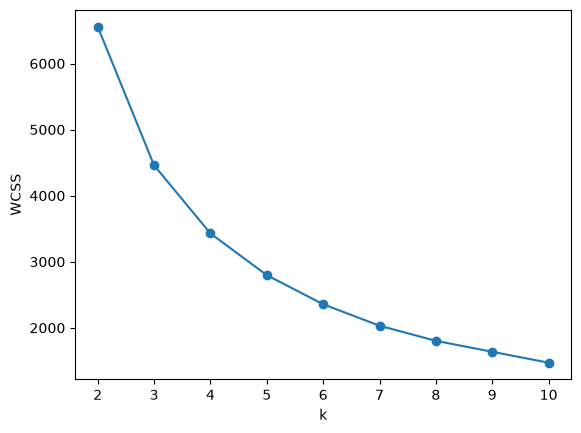

In [58]:
plt.plot(range(2, 11), wcss, marker="o")
plt.xlabel("k"); plt.ylabel("WCSS")
plt.show()

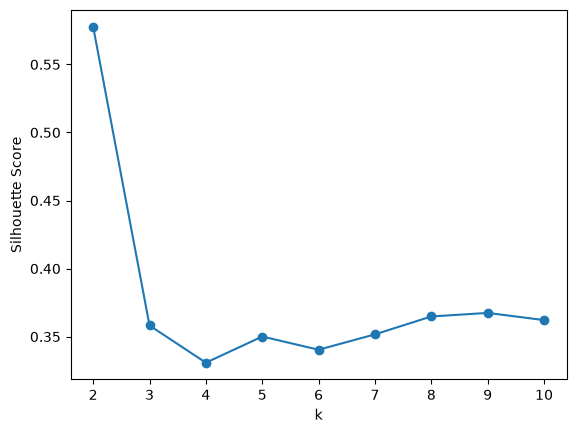

In [69]:
plt.plot(range(2, 11), ss, marker="o")
plt.xlabel("k")
plt.ylabel("Silhouette Score")
plt.xticks(range(2, 11))
plt.show()

In [60]:
final_model = KMeans(n_clusters=4, random_state=23, n_init=10)
rfm_df["Cluster"] = final_model.fit_predict(rfm_scaled)

In [62]:
print(silhouette_score(rfm_scaled, rfm_df["Cluster"]))

0.3308598371227425


In [63]:
rfm_df["Cluster"].value_counts().sort_index()

Cluster
0     752
1    1196
2      84
3    1022
Name: count, dtype: int64

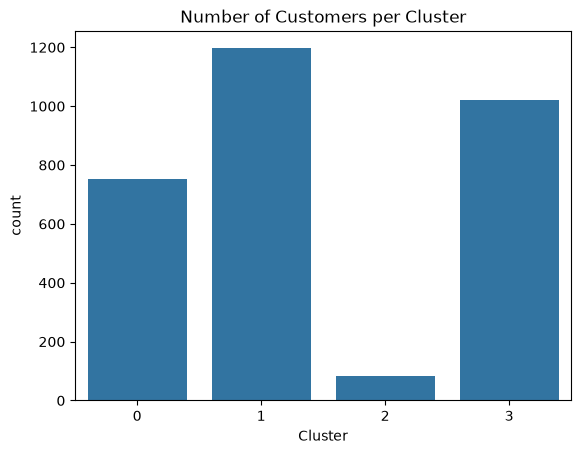

In [64]:
sns.countplot(x=rfm_df["Cluster"])
plt.title("Number of Customers per Cluster")
plt.show()

In [65]:
rfm_df.groupby("Cluster")[["Recency", "Frequency", "Monetary"]].agg(["mean", "median", "count"])

Recency              Frequency                 Monetary           \
               mean median count      mean median count        mean   median   
Cluster                                                                        
0         29.582447   26.0   752  1.035904    1.0   752   71.242021   53.740   
1        306.567726  259.0  1196  1.008361    1.0  1196   45.962383   43.670   
2        170.440476   88.0    84  5.392857    4.0    84  995.865119  454.245   
3        298.817025  261.5  1022  1.102740    1.0  1022  214.365049  136.830   

               
        count  
Cluster        
0         752  
1        1196  
2          84  
3        1022

In [67]:
revenue = rfm_df.groupby("Cluster").agg(Customers=("Customers.id", "count"),
                                        Revenue=("Monetary", "sum"))
revenue["Customer_%"] = revenue["Customers"] / revenue["Customers"].sum() * 100
revenue["Revenue_%"] = revenue["Revenue"] / revenue["Revenue"].sum() * 100
revenue.round(1)

,Customers,Revenue,Customer_%,Revenue_%
Cluster,,,,
0,752,53574.0,24.6,13.0
1,1196,54971.0,39.2,13.4
2,84,83652.7,2.8,20.3
3,1022,219081.1,33.5,53.3


In [68]:
segment_names = {2: "Loyal High-Value", 3: "Lapsed Big Spenders",
                 0: "New / Recent Low-Spend", 1: "Lapsed Low-Value"}
rfm_df["Segment"] = rfm_df["Cluster"].map(segment_names)

### Conclusion



The aim of this project was to segment the company's customers so that marketing can be targeted more effectively. Using Recency, Frequency and Monetary values, customers were grouped with K-Means into four segments.

The number of segments was chosen by combining the elbow method, the silhouette score and business sense. The within-cluster error falls sharply up to four clusters and flattens afterwards. Two clusters gave the highest silhouette score, but that solution only separated one-time buyers from repeat buyers, which is too broad to guide a campaign. Beyond three clusters the silhouette score barely changed, so four clusters offered the most useful level of detail without losing quality.

The four segments tell a clear story. A small group of loyal customers, fewer than 3% of the base, orders around five times on average and brings in about a fifth of all revenue. The largest share of revenue, more than half, comes from customers who made one sizeable purchase but have not returned for eight to nine months. A third group consists of recent first-time buyers with small baskets, and the largest group by number are customers who bought something small a long time ago and never came back.

These results point to different actions for each group. The loyal customers should be protected through a loyalty programme and personal attention. The lapsed big spenders represent the biggest opportunity, and a personalised win-back campaign could recover a significant part of their value. Recent buyers should be encouraged to make a second purchase, since that is the step that turns a one-time customer into a loyal one. The low-value lapsed group warrants only low-cost, automated reminders.

The analysis has some limitations. Around 93% of customers placed only one order, so the segments are shaped mainly by recency and spending rather than frequency. The data ends in May 2016, so recency was measured from that point, and undocumented order status codes meant that all orders were kept in the analysis.

In [70]:
conn.close()